# 09 — Model Diagnostics and Error Analysis

## Objective

This notebook **diagnoses model errors before hyperparameter tuning**. Notebook 08 identified **CatBoost + log_target_price** as the current best model, but strong error patterns remain.

The goal here is to understand *where* and *why* models make errors — not yet to fix them. We investigate:

| Diagnostic Area | Key Question |
|---|---|
| Heteroscedasticity | Does residual variance increase with actual price? |
| Price-segment bias | Are low-price laptops overpredicted? Premium laptops underpredicted? |
| Log-target compression | Does log-transform compress high-price predictions? |
| Feature-level bias | Are errors concentrated in specific brands or specs? |
| Outliers / data quality | Are some extreme errors valid hard cases or data noise? |
| Correction strategies | What simple post-hoc corrections reduce key error patterns? |

> **Important**: This notebook does not perform hyperparameter tuning. Correction experiments are exploratory only and are estimated on the test set. They are intended to guide tuning strategy, not to be reported as final model performance.

### Primary models diagnosed

1. **CatBoost + log_target_price** (main diagnostic model)
2. **CatBoost + target_price** (comparison for log-compression analysis)
3. **LightGBM + log_target_price**
4. **LightGBM + target_price**
5. **Extra Trees + log_target_price** (optional, if available)


## 2. Imports and Configuration

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import statsmodels.stats.diagnostic as sm_diag
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not available; formal heteroscedasticity tests will be skipped.")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# ── Paths ─────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed.csv'

ARTIFACT_DIR   = PROJECT_ROOT / 'artifacts' / 'modeling'
METRICS_DIR    = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
COMPARISON_DIR = ARTIFACT_DIR / 'target_comparison'
DIAGNOSTICS_DIR = ARTIFACT_DIR / 'model_diagnostics'

DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT   : {PROJECT_ROOT}')
print(f'DATA_PATH      : {DATA_PATH}')
print(f'DIAGNOSTICS_DIR: {DIAGNOSTICS_DIR}')


PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
DIAGNOSTICS_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling\model_diagnostics


## 3. Load Predictions, Metrics, and Original Data

We load artifacts saved by notebooks 07 and 08. No model retraining occurs unless artifacts are missing.

In [2]:
# ── Helper: safe filename (must match notebook 07 logic) ──────────────────────
MODEL_NAME_FOR_FILE = {
    'Linear Regression': 'LinearRegression',
    'Ridge': 'Ridge',
    'Lasso': 'Lasso',
    'ElasticNet': 'ElasticNet',
    'Random Forest': 'RandomForest',
    'Extra Trees': 'ExtraTrees',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'CatBoost': 'CatBoost',
}

def safe_filename(model_name: str, target_used: str) -> str:
    base = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(' ', ''))
    return f'{base}_{target_used}'


# ── Discover available files ──────────────────────────────────────────────────
print('=== Metrics files ===')
for f in sorted(METRICS_DIR.glob('*.csv')):
    print(f'  {f.name}')

print()
print('=== Predictions files ===')
for f in sorted(PREDICTIONS_DIR.glob('*.csv')):
    print(f'  {f.name}')

print()
print('=== Comparison files ===')
for f in sorted(COMPARISON_DIR.glob('*.csv')):
    print(f'  {f.name}')


=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Predictions files ===
  test_predictions.csv

=== Comparison files ===
  fine_tuning_candidates.csv
  model_family_metrics.csv
  model_family_performance_summary.csv
  target_comparison_error_by_price_segment.csv
  target_comparison_overall_ranking.csv
  target_comparison_pairwise_by_model.csv
  target_comparison_prediction_errors_long.csv
  target_comparison_summary_by_target.csv


In [3]:
# ── Load metrics ──────────────────────────────────────────────────────────────
metrics_df = None
for candidate in ['model_metrics.csv', 'metrics_df.csv', 'all_metrics.csv']:
    p = METRICS_DIR / candidate
    if p.exists():
        metrics_df = pd.read_csv(p)
        print(f'Loaded metrics: {candidate}  shape={metrics_df.shape}')
        break

if metrics_df is None:
    raise FileNotFoundError('No metrics CSV found. Run notebook 07 first.')

# Standardize column names
metrics_df.columns = [
    c.strip().lower().replace(' ', '_').replace('-', '_') for c in metrics_df.columns
]
metrics_df.rename(columns={
    'median_ae': 'median_absolute_error',
    'train_time_sec': 'training_time_seconds',
}, inplace=True)

# Ensure MAPE is in fraction form (0–1)
if 'mape' in metrics_df.columns and metrics_df['mape'].max() > 10:
    metrics_df['mape'] = metrics_df['mape'] / 100.0

display(metrics_df.sort_values('rmse').head(10))


Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,CatBoost,gradient_boosting,log_target_price,target_price,"3,252,280.8663","5,157,061.3893",0.8930,0.2771,"1,916,663.0917","37,608,943.3134",1.1344,0.0022
1,CatBoost,gradient_boosting,target_price,target_price,"3,362,703.2339","5,162,384.4059",0.8928,0.3314,"2,039,510.9310","36,580,025.3383",1.1833,0.0048
2,LightGBM,gradient_boosting,target_price,target_price,"3,371,062.7982","5,322,802.4342",0.8860,0.3160,"2,007,119.7696","38,350,151.4341",0.5240,0.0102
3,LightGBM,gradient_boosting,log_target_price,target_price,"3,309,789.3388","5,407,378.8236",0.8823,0.2770,"1,868,291.6436","40,782,927.3785",0.3695,0.0111
4,Random Forest,tree_ensemble,target_price,target_price,"3,412,705.0440","5,526,455.5762",0.8771,0.3124,"1,915,382.6300","48,433,650.0000",1.3356,0.1569
5,Random Forest,tree_ensemble,log_target_price,target_price,"3,367,907.0407","5,530,209.9654",0.8769,0.2901,"1,899,621.9828","38,524,138.4898",1.2858,0.1107
6,Extra Trees,tree_ensemble,log_target_price,target_price,"3,670,282.7920","6,143,809.8092",0.8481,0.3143,"1,994,764.5704","57,489,239.1507",1.4723,0.1393
7,Extra Trees,tree_ensemble,target_price,target_price,"3,766,407.0975","6,361,692.6960",0.8371,0.3357,"2,000,000.0000","68,972,766.6667",1.3908,0.1240
8,ElasticNet,linear,target_price,target_price,"4,340,622.3989","6,784,919.8876",0.8148,0.4449,"2,705,409.5432","77,725,809.6648",2.9982,0.0048
9,Ridge,linear,target_price,target_price,"4,340,805.3332","6,786,909.3092",0.8147,0.4450,"2,714,108.6220","77,900,063.2654",0.0215,0.0051


In [4]:
# ── Load test predictions (wide format from notebook 07) ──────────────────────
predictions_raw = None
for candidate in ['test_predictions.csv', 'predictions_df.csv', 'all_predictions.csv']:
    p = PREDICTIONS_DIR / candidate
    if p.exists():
        predictions_raw = pd.read_csv(p)
        print(f'Loaded predictions: {candidate}  shape={predictions_raw.shape}')
        break

if predictions_raw is None:
    # Fallback: any CSV with 'pred' columns
    for f in sorted(PREDICTIONS_DIR.glob('*.csv')):
        try:
            df_try = pd.read_csv(f)
            if any('pred' in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                print(f'Fallback predictions: {f.name}  shape={predictions_raw.shape}')
                break
        except Exception:
            continue

if predictions_raw is None:
    raise FileNotFoundError('No predictions CSV found. Run notebook 07 first.')

display(predictions_raw.head())
print('Columns:', predictions_raw.columns.tolist())


Loaded predictions: test_predictions.csv  shape=(1461, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,5152,"3,000,000.0000","3,931,164.6882","4,966,023.2076","4,225,859.5786","4,989,566.4783","4,227,396.6632","5,003,818.1943","4,222,950.9802","4,995,150.6832","5,649,693.9538","5,572,367.2828","5,662,499.8750","5,586,869.7627","5,635,967.4847","5,456,175.9328","5,433,546.8956","5,332,942.4444"
1,5456,"16,900,000.0000","20,577,308.6882","16,227,405.8391","19,897,861.1602","16,248,697.6906","19,891,273.2192","15,911,442.9715","19,910,389.0887","16,043,983.0574","19,875,990.1587","20,086,916.4589","21,990,000.0000","21,990,000.0000","19,977,147.8212","19,764,235.7406","22,004,586.9222","21,127,682.0992"
2,3859,"13,000,000.0000","2,464,796.6882","4,146,672.5200","2,861,038.5316","4,251,053.4022","2,856,633.6336","4,284,992.7841","2,869,454.9405","4,269,001.9809","7,198,587.7778","5,693,424.5419","6,813,025.5556","5,549,168.8507","7,047,357.7268","5,802,408.9878","6,709,287.2732","6,032,026.1401"
3,1918,"16,500,000.0000","28,335,132.6882","26,182,201.5742","28,543,998.8426","26,010,771.4076","28,541,799.2674","25,807,941.9252","28,548,172.1321","25,943,261.5151","20,754,882.7778","19,118,057.8755","18,848,000.0000","16,109,693.3012","23,853,959.0654","21,025,240.8960","23,107,973.1835","19,923,761.2752"
4,7300,"24,200,000.0000","29,187,100.6882","24,476,097.6576","28,426,357.9087","25,591,341.0604","28,427,910.1511","25,897,150.5844","28,423,384.6345","25,753,309.8470","26,139,094.4444","25,677,034.6865","29,227,713.3333","26,937,147.0918","23,459,138.3782","22,224,618.3244","23,999,598.8535","24,492,739.7362"


Columns: ['sample_id', 'y_true_price', 'pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [5]:
# ── Load original processed data ──────────────────────────────────────────────
df_orig = pd.read_csv(DATA_PATH)
TARGET_COLUMNS = ['target_price', 'log_target_price']
feature_cols = [c for c in df_orig.columns if c not in TARGET_COLUMNS]

print(f'Original data shape: {df_orig.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols[:10]} ...')

# Check for useful categorical features
LIKELY_CAT_COLS = [
    'brand', 'cpu', 'gpu', 'ram', 'storage', 'screen_size',
    'operating_system', 'laptop_type', 'product_type',
    'cpu_brand', 'gpu_brand', 'gpu_type',
]
available_cat_cols = [c for c in LIKELY_CAT_COLS if c in df_orig.columns]
print(f'Available categorical-ish columns: {available_cat_cols}')


Original data shape: (7304, 60)
Feature columns (58): ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'cpu_missing', 'gpu_missing'] ...
Available categorical-ish columns: []


In [6]:
# ── Attempt to merge features into predictions ────────────────────────────────
# predictions_raw has sample_id = original df index
merge_ok = False

if 'sample_id' in predictions_raw.columns:
    try:
        predictions_with_features = predictions_raw.merge(
            df_orig[feature_cols].reset_index().rename(columns={'index': 'sample_id'}),
            on='sample_id',
            how='left'
        )
        merge_ok = predictions_with_features[available_cat_cols[0] if available_cat_cols else feature_cols[0]].notna().mean() > 0.9
        if merge_ok:
            print(f'Feature merge successful. Shape: {predictions_with_features.shape}')
    except Exception as e:
        print(f'Feature merge failed: {e}')

if not merge_ok:
    predictions_with_features = predictions_raw.copy()
    print('Feature-level diagnostics will be limited (merge not available).')


Feature merge successful. Shape: (1461, 76)


## 4. Build Diagnostic Error Dataset

We reshape predictions from wide format (one column per model) to long format (one row per sample × model). This makes it easy to filter, group, and compare errors across models and price segments.

In [7]:
# ── Define primary models to diagnose ────────────────────────────────────────
PRIMARY_MODELS = [
    ('CatBoost', 'log_target_price'),
    ('CatBoost', 'target_price'),
    ('LightGBM', 'log_target_price'),
    ('LightGBM', 'target_price'),
    ('Extra Trees', 'log_target_price'),
]

# ── Build long-format diagnostic dataframe ────────────────────────────────────
if 'y_true_price' in predictions_raw.columns:
    actual_col = 'y_true_price'
elif 'actual_price' in predictions_raw.columns:
    actual_col = 'actual_price'
else:
    raise ValueError('Cannot find actual price column in predictions. Check predictions CSV.')

diag_rows = []
available_models = []

for model_name, target_used in PRIMARY_MODELS:
    col = f'pred_{safe_filename(model_name, target_used)}'
    if col not in predictions_raw.columns:
        print(f'  Skipping {model_name} + {target_used}: column "{col}" not found.')
        continue
    available_models.append((model_name, target_used))

    actual = predictions_raw[actual_col].values
    predicted = predictions_raw[col].values
    sample_id = (
        predictions_raw['sample_id'].values
        if 'sample_id' in predictions_raw.columns
        else np.arange(len(predictions_raw))
    )

    residual = actual - predicted
    abs_error = np.abs(residual)
    pct_error = residual / (actual + 1e-9)
    abs_pct_error = abs_error / (actual + 1e-9)

    for i in range(len(actual)):
        diag_rows.append({
            'sample_id': sample_id[i],
            'actual_price': actual[i],
            'predicted_price': predicted[i],
            'residual': residual[i],
            'absolute_error': abs_error[i],
            'squared_error': residual[i] ** 2,
            'percentage_error': pct_error[i],
            'absolute_percentage_error': abs_pct_error[i],
            'prediction_ratio': predicted[i] / (actual[i] + 1e-9),
            'model_name': model_name,
            'target_used': target_used,
        })

diag_df = pd.DataFrame(diag_rows)
print(f'Diagnostic dataframe shape: {diag_df.shape}')
print(f'Models included: {available_models}')


Diagnostic dataframe shape: (7305, 11)
Models included: [('CatBoost', 'log_target_price'), ('CatBoost', 'target_price'), ('LightGBM', 'log_target_price'), ('LightGBM', 'target_price'), ('Extra Trees', 'log_target_price')]


In [8]:
# ── Add price segments ─────────────────────────────────────────────────────────
# Quantiles based on unique actual prices across the diagnostic set
q25, q50, q75 = np.quantile(predictions_raw[actual_col].values, [0.25, 0.50, 0.75])
print(f'Price quantiles: Q25={q25:,.0f}  Q50={q50:,.0f}  Q75={q75:,.0f}')

def assign_segment(price):
    if price <= q25:
        return 'Low'
    elif price <= q50:
        return 'Mid'
    elif price <= q75:
        return 'High'
    else:
        return 'Premium'

diag_df['price_segment'] = diag_df['actual_price'].apply(assign_segment)
diag_df['price_segment'] = pd.Categorical(
    diag_df['price_segment'], categories=['Low', 'Mid', 'High', 'Premium'], ordered=True
)

print()
print('Segment counts (per sample, for main model):')
main_mask = (diag_df['model_name'] == 'CatBoost') & (diag_df['target_used'] == 'log_target_price')
print(diag_df[main_mask]['price_segment'].value_counts().sort_index())

# Save
diag_df.to_csv(DIAGNOSTICS_DIR / 'diagnostic_errors_long.csv', index=False)
print('\nSaved: diagnostic_errors_long.csv')


Price quantiles: Q25=5,900,000  Q50=10,480,000  Q75=18,900,000

Segment counts (per sample, for main model):
price_segment
Low        377
Mid        354
High       371
Premium    359
Name: count, dtype: int64

Saved: diagnostic_errors_long.csv


## 5. Overall Error Diagnostics

We summarize the key error statistics for each primary model. Beyond the standard metrics (MAE, RMSE, MAPE), we also track:

- **Mean / median residual**: are predictions centered around zero, or is there systematic bias?
- **Underprediction rate**: proportion of cases where `actual > predicted`
- **Severe error rate**: proportion with absolute percentage error > 50%
- **Extreme error rate**: proportion with absolute percentage error > 100%

In [9]:
summary_rows = []

for (model_name, target_used), grp in diag_df.groupby(['model_name', 'target_used'], observed=True):
    yt = grp['actual_price'].values
    yp = grp['predicted_price'].values
    res = grp['residual'].values
    ape = grp['absolute_percentage_error'].values

    summary_rows.append({
        'model_name': model_name,
        'target_used': target_used,
        'n': len(yt),
        'mae': mean_absolute_error(yt, yp),
        'rmse': root_mean_squared_error(yt, yp),
        'mape': mean_absolute_percentage_error(yt, yp),
        'median_absolute_error': median_absolute_error(yt, yp),
        'mean_residual': res.mean(),
        'median_residual': np.median(res),
        'residual_std': res.std(),
        'underprediction_rate': (res > 0).mean(),
        'overprediction_rate': (res < 0).mean(),
        'severe_error_rate': (ape > 0.50).mean(),
        'extreme_error_rate': (ape > 1.00).mean(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('rmse').reset_index(drop=True)
summary_df.to_csv(DIAGNOSTICS_DIR / 'diagnostic_model_error_summary.csv', index=False)

print('=== Overall Error Summary ===')
display(summary_df)


=== Overall Error Summary ===


,model_name,target_used,n,mae,rmse,mape,median_absolute_error,mean_residual,median_residual,residual_std,underprediction_rate,overprediction_rate,severe_error_rate,extreme_error_rate
0,CatBoost,log_target_price,1461,"3,252,280.8663","5,157,061.3893",0.2771,"1,916,663.0917","611,154.9695","162,882.2288","5,120,719.8494",0.5195,0.4805,0.1143,0.0267
1,CatBoost,target_price,1461,"3,362,703.2339","5,162,384.4059",0.3314,"2,039,510.9310","-171,399.3706","-311,773.8523","5,159,538.2555",0.4531,0.5469,0.1622,0.0507
2,LightGBM,target_price,1461,"3,371,062.7982","5,322,802.4342",0.3160,"2,007,119.7696","64,320.2566","-135,030.1661","5,322,413.8000",0.4798,0.5202,0.1526,0.0438
3,LightGBM,log_target_price,1461,"3,309,789.3388","5,407,378.8236",0.2770,"1,868,291.6436","649,973.7154","210,106.7711","5,368,172.8653",0.5352,0.4648,0.1177,0.0267
4,Extra Trees,log_target_price,1461,"3,670,282.7920","6,143,809.8092",0.3143,"1,994,764.5704","275,391.3345","161,203.5242","6,137,634.6083",0.5325,0.4675,0.1663,0.0438


In [10]:
# ── Interpretation ─────────────────────────────────────────────────────────────
main_row = summary_df[
    (summary_df['model_name'] == 'CatBoost') & (summary_df['target_used'] == 'log_target_price')
].iloc[0]

print(f"=== CatBoost + log_target_price — Interpretation ===")
print(f"  Mean residual   : {main_row['mean_residual']:,.0f}")
print(f"  Median residual : {main_row['median_residual']:,.0f}")
mr = main_row['mean_residual']
if abs(mr) < 1e5:
    print("  ✓ Residuals appear roughly centered around zero.")
elif mr > 0:
    print("  ⚠ Positive mean residual → model tends to underpredict on average.")
else:
    print("  ⚠ Negative mean residual → model tends to overpredict on average.")

print(f"  Underprediction rate: {main_row['underprediction_rate']:.1%}")
print(f"  Overprediction  rate: {main_row['overprediction_rate']:.1%}")
print(f"  Severe error rate (APE>50%): {main_row['severe_error_rate']:.1%}")
print(f"  Extreme error rate (APE>100%): {main_row['extreme_error_rate']:.1%}")


=== CatBoost + log_target_price — Interpretation ===
  Mean residual   : 611,155
  Median residual : 162,882
  ⚠ Positive mean residual → model tends to underpredict on average.
  Underprediction rate: 52.0%
  Overprediction  rate: 48.0%
  Severe error rate (APE>50%): 11.4%
  Extreme error rate (APE>100%): 2.7%


## 6. Heteroscedasticity Diagnosis

**Heteroscedasticity** means that residual variance is not constant across the range of actual prices. If errors become larger as actual price increases, the model's predictions are less reliable at the upper end of the price range.

> Note: Heteroscedasticity is formally an OLS assumption. For tree-based models, it does not invalidate the model, but it does affect how we interpret aggregate metrics like RMSE and motivates segment-aware evaluation or sample weighting during tuning.

We assess this by:
1. Plotting residuals against actual price
2. Plotting absolute error against actual price
3. Plotting percentage error against actual price
4. Binned residual variance table
5. Correlation tests between actual price and error magnitude

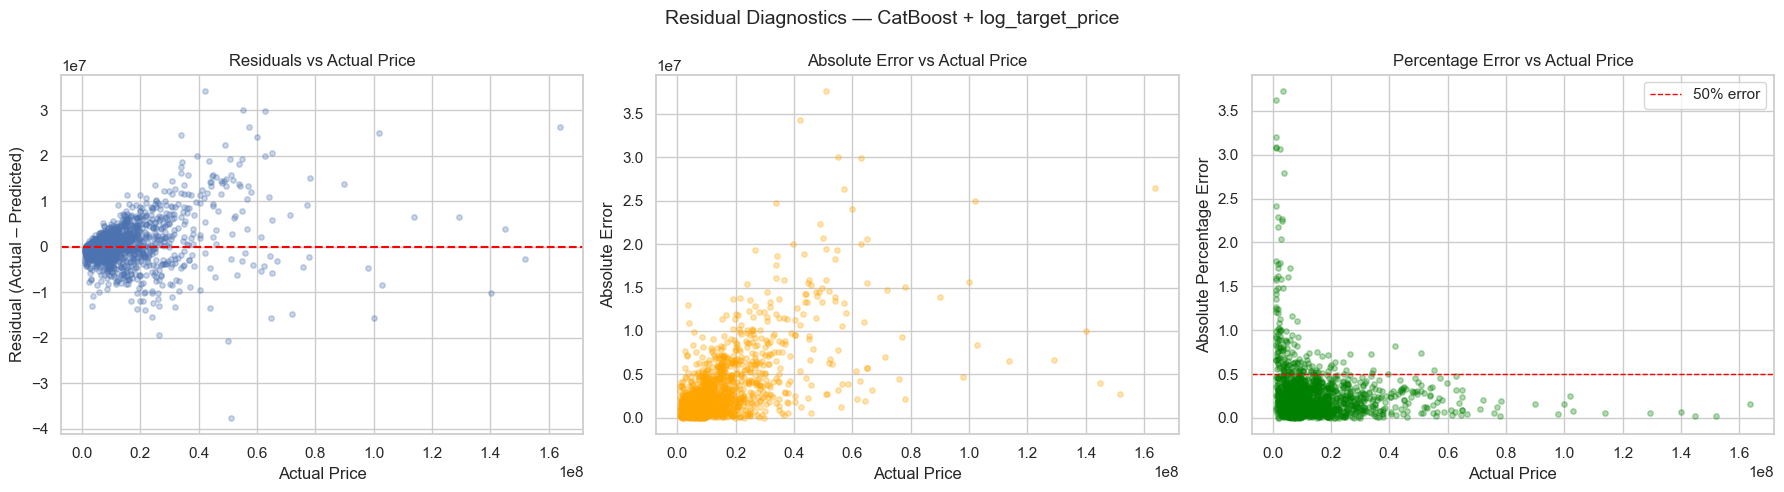

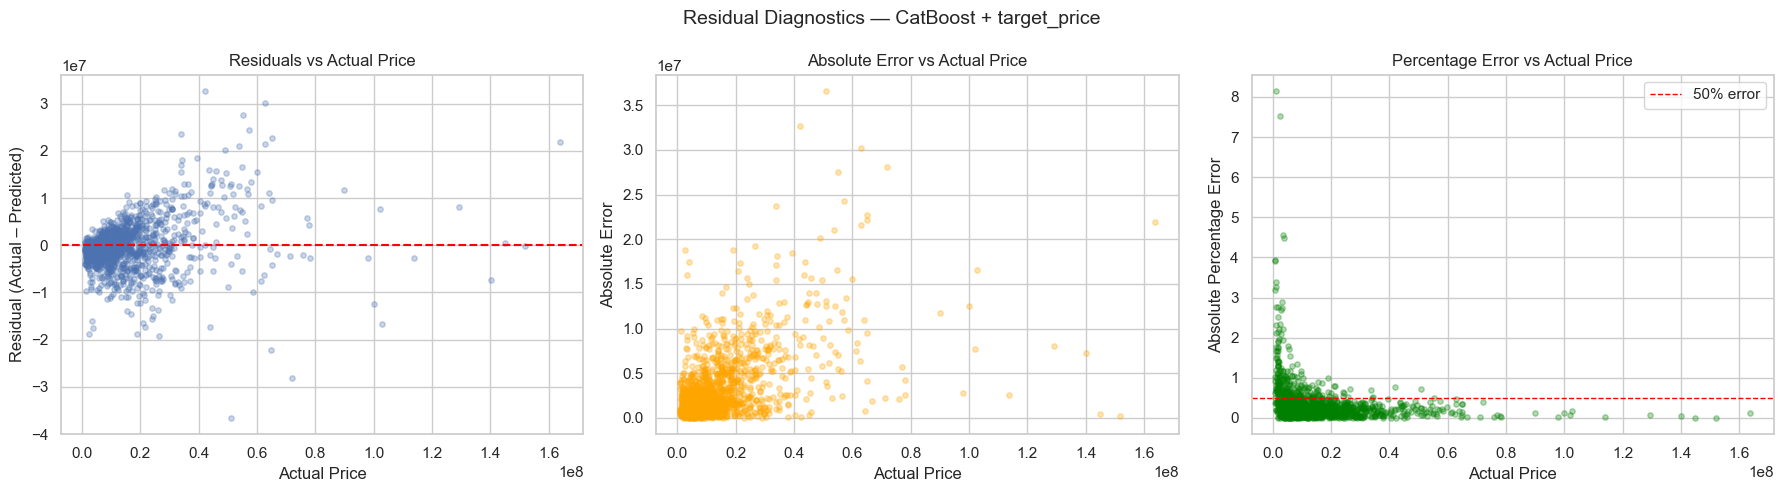

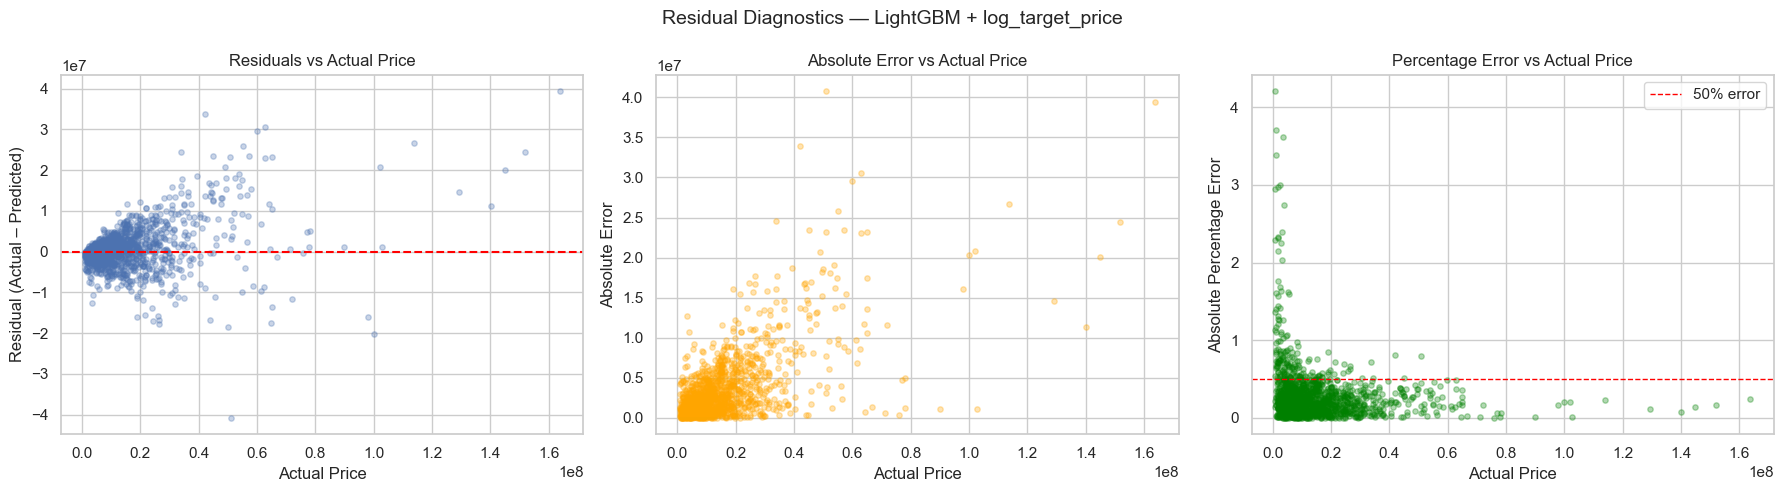

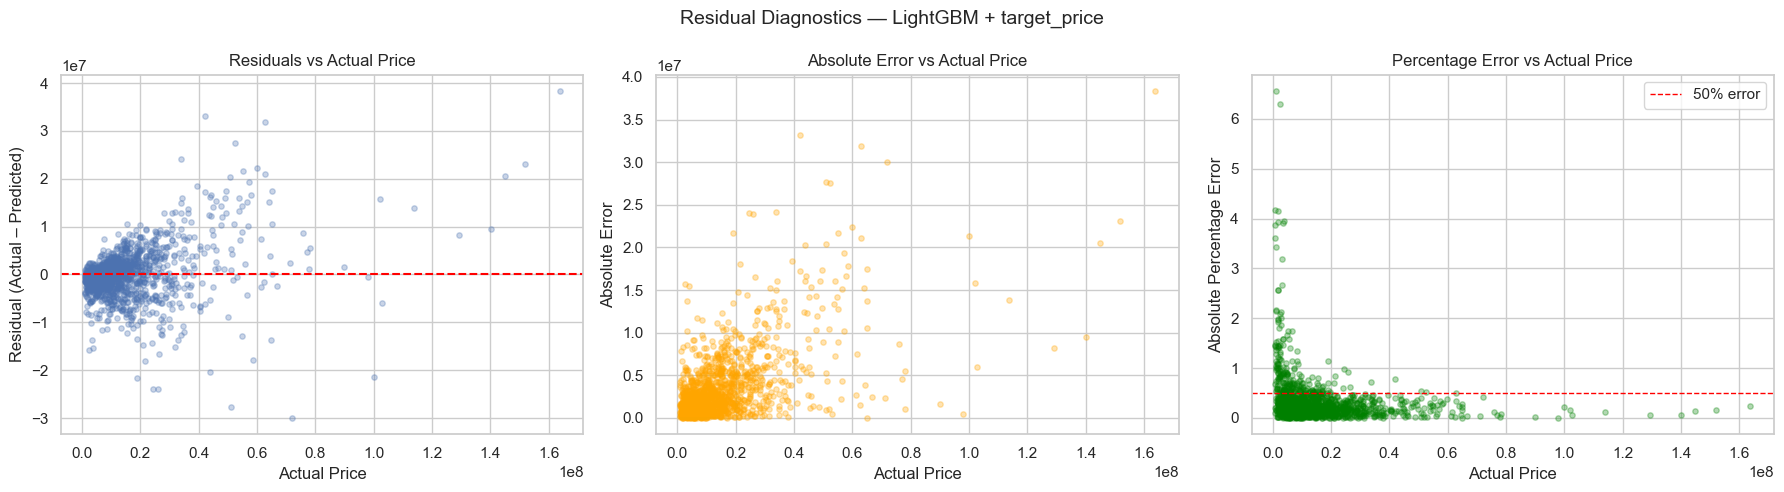

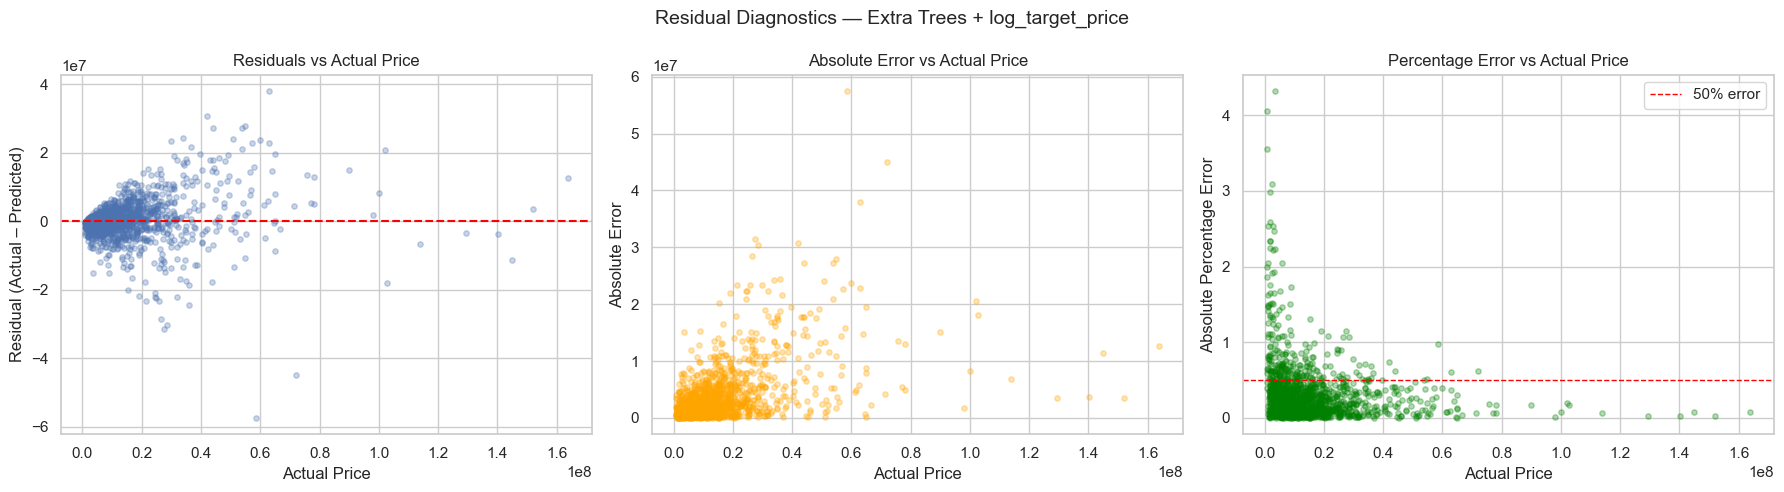

In [11]:
def plot_heteroscedasticity(diag_df, model_name, target_used, save_dir):
    """Generate three residual scatter plots for a given model."""
    mask = (diag_df['model_name'] == model_name) & (diag_df['target_used'] == target_used)
    grp = diag_df[mask]
    label = f'{model_name} + {target_used}'
    fn_suffix = safe_filename(model_name, target_used)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Residual Diagnostics — {label}', fontsize=14)

    # Residuals vs actual price
    axes[0].scatter(grp['actual_price'], grp['residual'], alpha=0.3, s=15)
    axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
    axes[0].set_xlabel('Actual Price')
    axes[0].set_ylabel('Residual (Actual – Predicted)')
    axes[0].set_title('Residuals vs Actual Price')

    # Absolute error vs actual price
    axes[1].scatter(grp['actual_price'], grp['absolute_error'], alpha=0.3, s=15, color='orange')
    axes[1].set_xlabel('Actual Price')
    axes[1].set_ylabel('Absolute Error')
    axes[1].set_title('Absolute Error vs Actual Price')

    # Percentage error vs actual price
    axes[2].scatter(grp['actual_price'], grp['absolute_percentage_error'], alpha=0.3, s=15, color='green')
    axes[2].axhline(0.5, color='red', linewidth=1, linestyle='--', label='50% error')
    axes[2].set_xlabel('Actual Price')
    axes[2].set_ylabel('Absolute Percentage Error')
    axes[2].set_title('Percentage Error vs Actual Price')
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(save_dir / f'heteroscedasticity_{fn_suffix}.png', dpi=150, bbox_inches='tight')
    plt.show()


for model_name, target_used in available_models:
    plot_heteroscedasticity(diag_df, model_name, target_used, DIAGNOSTICS_DIR)


In [12]:
# ── Binned residual variance table ────────────────────────────────────────────
het_rows = []

for (model_name, target_used), grp in diag_df.groupby(['model_name', 'target_used'], observed=True):
    grp = grp.copy()
    grp['price_bin'] = pd.qcut(grp['actual_price'], q=10, duplicates='drop')

    for bin_label, bin_grp in grp.groupby('price_bin', observed=True):
        yt = bin_grp['actual_price'].values
        yp = bin_grp['predicted_price'].values
        res = bin_grp['residual'].values
        het_rows.append({
            'model_name': model_name,
            'target_used': target_used,
            'price_bin': str(bin_label),
            'price_min': yt.min(),
            'price_max': yt.max(),
            'count': len(yt),
            'residual_std': res.std(),
            'absolute_error_mean': bin_grp['absolute_error'].mean(),
            'rmse': root_mean_squared_error(yt, yp),
            'mape': mean_absolute_percentage_error(yt, yp),
        })

het_df = pd.DataFrame(het_rows)
het_df.to_csv(DIAGNOSTICS_DIR / 'heteroscedasticity_binned_error_summary.csv', index=False)

# Display for main model
print('=== Binned Residual Variance — CatBoost + log_target_price ===')
display(
    het_df[
        (het_df['model_name'] == 'CatBoost') & (het_df['target_used'] == 'log_target_price')
    ][['price_bin', 'price_min', 'price_max', 'count', 'residual_std', 'absolute_error_mean', 'rmse', 'mape']]
)


=== Binned Residual Variance — CatBoost + log_target_price ===


,price_bin,price_min,price_max,count,residual_std,absolute_error_mean,rmse,mape
0,"(999999.999, 3300000.0]","1,000,000.0000","3,300,000.0000",149,"1,542,382.1887","1,314,961.0114","1,919,500.6937",0.6957
1,"(3300000.0, 4999999.0]","3,350,000.0000","4,999,999.0000",144,"1,929,014.3227","1,301,227.7543","2,065,543.9942",0.3191
2,"(4999999.0, 6600000.0]","5,000,000.0000","6,600,000.0000",148,"2,008,524.9053","1,361,016.6506","2,029,594.4796",0.2338
3,"(6600000.0, 8200000.0]","6,630,000.0000","8,200,000.0000",147,"1,945,927.3546","1,545,110.5707","1,953,815.2866",0.2087
4,"(8200000.0, 10480000.0]","8,300,000.0000","10,480,000.0000",143,"2,852,220.0011","2,273,129.0424","2,913,965.4430",0.2476
5,"(10480000.0, 13000000.0]","10,490,000.0000","13,000,000.0000",146,"3,098,242.6855","2,530,295.5834","3,137,216.9372",0.2177
6,"(13000000.0, 16500000.0]","13,190,000.0000","16,500,000.0000",151,"4,058,704.9891","3,366,764.5460","4,133,827.4350",0.2262
7,"(16500000.0, 21500000.0]","16,550,000.0000","21,500,000.0000",145,"4,937,969.2932","3,851,789.5669","4,947,308.5431",0.2023
8,"(21500000.0, 30990000.0]","21,600,000.0000","30,990,000.0000",144,"6,242,606.9018","5,231,478.2109","6,397,478.6417",0.2010
9,"(30990000.0, 163790000.0]","31,000,000.0000","163,790,000.0000",144,"10,862,528.6003","9,895,904.4157","12,317,384.8404",0.2100


In [13]:
# ── Correlation tests ─────────────────────────────────────────────────────────
print('=== Correlation: Actual Price vs Error Magnitude (CatBoost + log_target_price) ===')
main_grp = diag_df[
    (diag_df['model_name'] == 'CatBoost') & (diag_df['target_used'] == 'log_target_price')
]

for err_col in ['absolute_error', 'squared_error']:
    r_actual, p_actual = stats.spearmanr(main_grp['actual_price'], main_grp[err_col])
    r_pred, p_pred = stats.spearmanr(main_grp['predicted_price'], main_grp[err_col])
    print(f'  actual_price vs {err_col}: rho={r_actual:.3f}, p={p_actual:.4f}')
    print(f'  predicted_price vs {err_col}: rho={r_pred:.3f}, p={p_pred:.4f}')
    print()

r_main, p_main = stats.spearmanr(main_grp['actual_price'], main_grp['absolute_error'])
if r_main > 0.3 and p_main < 0.05:
    print('⚠ Positive correlation between actual price and absolute error — heteroscedasticity detected.')
    print('  This does not invalidate tree-based models but motivates segment-aware evaluation or sample weighting.')
else:
    print('✓ No strong correlation between actual price and absolute error.')

# Optional statsmodels test
if HAS_STATSMODELS:
    import statsmodels.api as sm
    print('\n=== Diagnostic Regression: squared residuals ~ predicted_price ===')
    print('(Informational only — not a formal OLS test for tree models)')
    X_sm = sm.add_constant(main_grp['predicted_price'].values)
    y_sm = main_grp['squared_error'].values
    ols_res = sm.OLS(y_sm, X_sm).fit()
    print(f'  R² = {ols_res.rsquared:.4f}')
    print(f'  Coefficient on predicted_price: {ols_res.params[1]:.4e}  p={ols_res.pvalues[1]:.4f}')
    if ols_res.pvalues[1] < 0.05:
        print('  ⚠ Squared residuals are significantly predicted by predicted_price → supports heteroscedasticity.')
    else:
        print('  ✓ No significant relationship between squared residuals and predicted_price.')


=== Correlation: Actual Price vs Error Magnitude (CatBoost + log_target_price) ===
  actual_price vs absolute_error: rho=0.561, p=0.0000
  predicted_price vs absolute_error: rho=0.546, p=0.0000

  actual_price vs squared_error: rho=0.561, p=0.0000
  predicted_price vs squared_error: rho=0.546, p=0.0000

⚠ Positive correlation between actual price and absolute error — heteroscedasticity detected.
  This does not invalidate tree-based models but motivates segment-aware evaluation or sample weighting.

=== Diagnostic Regression: squared residuals ~ predicted_price ===
(Informational only — not a formal OLS test for tree models)
  R² = 0.1446
  Coefficient on predicted_price: 2.1472e+06  p=0.0000
  ⚠ Squared residuals are significantly predicted by predicted_price → supports heteroscedasticity.


## 7. Price Segment Bias Analysis

We compute error metrics and bias indicators for each price segment (Low / Mid / High / Premium).

- A **negative mean residual** (actual − predicted < 0) means the model *overpredicts* in that segment.
- A **positive mean residual** means the model *underpredicts*.
- A **prediction_ratio > 1** means the model predicts higher than actual (overprediction).

In [14]:
seg_rows = []

for (model_name, target_used, segment), grp in diag_df.groupby(
    ['model_name', 'target_used', 'price_segment'], observed=True
):
    yt = grp['actual_price'].values
    yp = grp['predicted_price'].values
    res = grp['residual'].values

    seg_rows.append({
        'model_name': model_name,
        'target_used': target_used,
        'price_segment': segment,
        'count': len(yt),
        'mae': mean_absolute_error(yt, yp),
        'rmse': root_mean_squared_error(yt, yp),
        'mape': mean_absolute_percentage_error(yt, yp),
        'median_absolute_error': median_absolute_error(yt, yp),
        'mean_residual': res.mean(),
        'median_residual': np.median(res),
        'underprediction_rate': (res > 0).mean(),
        'overprediction_rate': (res < 0).mean(),
        'prediction_ratio_mean': grp['prediction_ratio'].mean(),
        'prediction_ratio_median': grp['prediction_ratio'].median(),
    })

seg_df = pd.DataFrame(seg_rows)
seg_df.to_csv(DIAGNOSTICS_DIR / 'price_segment_bias_summary.csv', index=False)

print('=== Segment Bias Summary (CatBoost models) ===')
display(
    seg_df[seg_df['model_name'] == 'CatBoost']
    [['model_name', 'target_used', 'price_segment', 'count', 'mae', 'rmse', 'mape', 'mean_residual', 'underprediction_rate', 'overprediction_rate', 'prediction_ratio_mean']]
)


=== Segment Bias Summary (CatBoost models) ===


,model_name,target_used,price_segment,count,mae,rmse,mape,mean_residual,underprediction_rate,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,Low,377,"1,324,700.2671","2,027,327.1766",0.4529,"-882,290.4604",0.2997,0.7003,1.3467
1,CatBoost,log_target_price,Mid,354,"1,800,884.6268","2,376,269.4091",0.2247,"-131,868.8774",0.5508,0.4492,1.0103
2,CatBoost,log_target_price,High,371,"3,025,645.2937","3,759,949.1275",0.2149,"684,559.8684",0.6038,0.3962,0.9539
3,CatBoost,log_target_price,Premium,359,"6,941,901.9028","9,150,915.4961",0.2082,"2,836,297.4523",0.6323,0.3677,0.9303
4,CatBoost,target_price,Low,377,"1,796,232.2462","2,854,866.2109",0.6318,"-1,476,898.7683",0.2175,0.7825,1.5354
5,CatBoost,target_price,Mid,354,"2,053,207.3597","2,794,218.8951",0.2563,"-605,343.8161",0.4887,0.5113,1.0698
6,CatBoost,target_price,High,371,"3,183,555.1234","4,072,175.8522",0.2256,"-143,213.0583",0.5418,0.4582,1.0114
7,CatBoost,target_price,Premium,359,"6,484,110.0605","8,663,831.6544",0.1994,"1,598,328.9993",0.5738,0.4262,0.9706


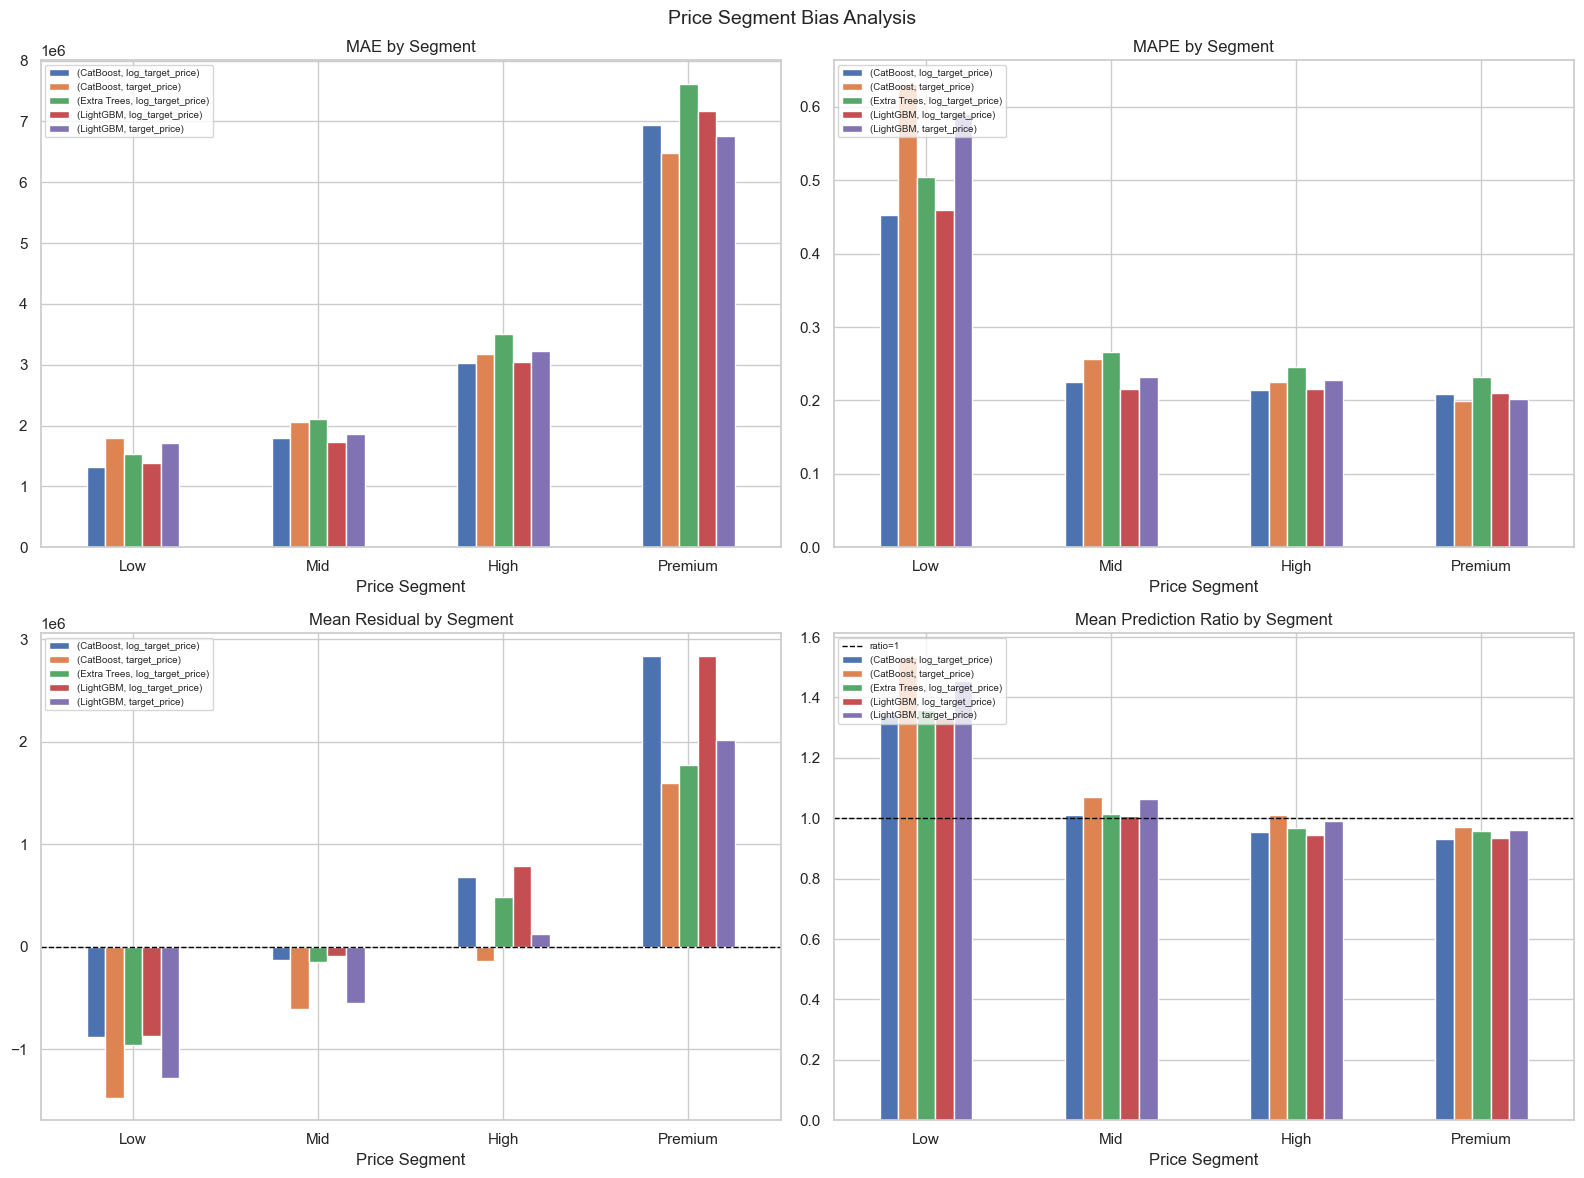

In [15]:
# ── Segment bias plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price Segment Bias Analysis', fontsize=14)

plot_models = seg_df['model_name'].unique()
segments_order = ['Low', 'Mid', 'High', 'Premium']

for ax, metric, title in zip(
    axes.flatten(),
    ['mae', 'mape', 'mean_residual', 'prediction_ratio_mean'],
    ['MAE by Segment', 'MAPE by Segment', 'Mean Residual by Segment', 'Mean Prediction Ratio by Segment'],
):
    pivot = seg_df.pivot_table(index='price_segment', columns=['model_name', 'target_used'], values=metric)
    pivot = pivot.reindex(segments_order)
    pivot.plot(kind='bar', ax=ax, legend=True)
    if metric == 'mean_residual':
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
    if metric == 'prediction_ratio_mean':
        ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='ratio=1')
    ax.set_title(title)
    ax.set_xlabel('Price Segment')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / 'price_segment_bias_plots.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# ── Segment bias interpretation ───────────────────────────────────────────────
for model_name, target_used in [('CatBoost', 'log_target_price'), ('CatBoost', 'target_price')]:
    mask = (seg_df['model_name'] == model_name) & (seg_df['target_used'] == target_used)
    s = seg_df[mask].set_index('price_segment')
    print(f'\n=== {model_name} + {target_used} — Segment Interpretation ===')
    for seg in ['Low', 'Premium']:
        if seg not in s.index:
            continue
        row = s.loc[seg]
        direction = 'underpredicts' if row['mean_residual'] > 0 else 'overpredicts'
        print(f"  {seg}: mean_residual={row['mean_residual']:,.0f}  ({direction})  "
              f"over_rate={row['overprediction_rate']:.1%}  under_rate={row['underprediction_rate']:.1%}")



=== CatBoost + log_target_price — Segment Interpretation ===
  Low: mean_residual=-882,290  (overpredicts)  over_rate=70.0%  under_rate=30.0%
  Premium: mean_residual=2,836,297  (underpredicts)  over_rate=36.8%  under_rate=63.2%

=== CatBoost + target_price — Segment Interpretation ===
  Low: mean_residual=-1,476,899  (overpredicts)  over_rate=78.2%  under_rate=21.8%
  Premium: mean_residual=1,598,329  (underpredicts)  over_rate=42.6%  under_rate=57.4%


## 8. Premium Segment Deep Dive

We focus on Premium laptops (actual price > Q75) to understand underprediction patterns. CatBoost + log_target_price is the primary subject; CatBoost + target_price is used for comparison.

In [17]:
premium_mask = diag_df['price_segment'] == 'Premium'
premium_df = diag_df[premium_mask].copy()

print('=== Premium Segment — Summary ===')
prem_rows = []
for (model_name, target_used), grp in premium_df.groupby(['model_name', 'target_used'], observed=True):
    yt = grp['actual_price'].values
    yp = grp['predicted_price'].values
    res = grp['residual'].values
    prem_rows.append({
        'model_name': model_name,
        'target_used': target_used,
        'count': len(yt),
        'mae': mean_absolute_error(yt, yp),
        'rmse': root_mean_squared_error(yt, yp),
        'mape': mean_absolute_percentage_error(yt, yp),
        'mean_residual': res.mean(),
        'underprediction_rate': (res > 0).mean(),
        'prediction_ratio_mean': grp['prediction_ratio'].mean(),
        'prediction_ratio_median': grp['prediction_ratio'].median(),
    })

prem_summary = pd.DataFrame(prem_rows)
prem_summary.to_csv(DIAGNOSTICS_DIR / 'premium_segment_diagnostics.csv', index=False)
display(prem_summary)


=== Premium Segment — Summary ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,underprediction_rate,prediction_ratio_mean,prediction_ratio_median
0,CatBoost,log_target_price,359,"6,941,901.9028","9,150,915.4961",0.2082,"2,836,297.4523",0.6323,0.9303,0.9182
1,CatBoost,target_price,359,"6,484,110.0605","8,663,831.6544",0.1994,"1,598,328.9993",0.5738,0.9706,0.9605
2,Extra Trees,log_target_price,359,"7,623,315.8698","10,822,443.8233",0.2322,"1,769,073.4713",0.6156,0.9582,0.9447
3,LightGBM,log_target_price,359,"7,176,607.5646","9,702,392.4713",0.2107,"2,840,507.7515",0.6351,0.9349,0.9193
4,LightGBM,target_price,359,"6,764,156.0638","9,170,723.3426",0.2023,"2,020,591.5057",0.6045,0.9606,0.9313


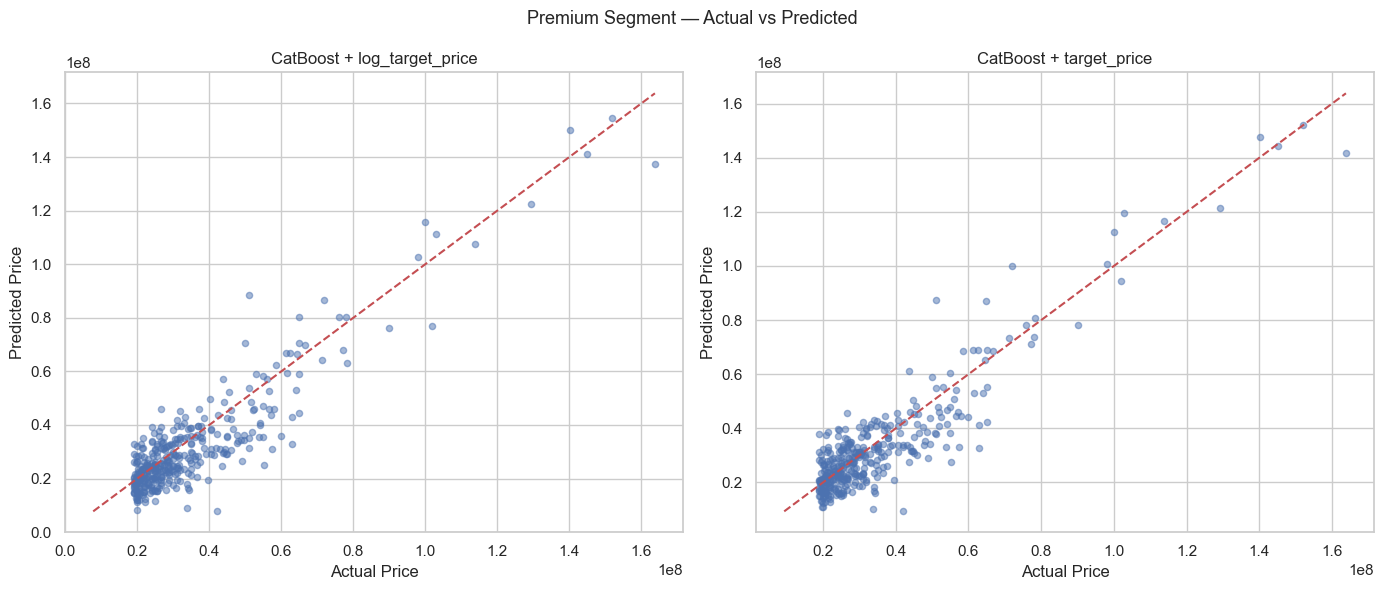

In [18]:
# ── Premium: actual vs predicted plots ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Premium Segment — Actual vs Predicted', fontsize=13)

for ax, (model_name, target_used) in zip(
    axes,
    [('CatBoost', 'log_target_price'), ('CatBoost', 'target_price')]
):
    mask = (
        (premium_df['model_name'] == model_name) &
        (premium_df['target_used'] == target_used)
    )
    grp = premium_df[mask]
    if grp.empty:
        ax.set_visible(False)
        continue
    ax.scatter(grp['actual_price'], grp['predicted_price'], alpha=0.5, s=20)
    lim_min = min(grp['actual_price'].min(), grp['predicted_price'].min())
    lim_max = max(grp['actual_price'].max(), grp['predicted_price'].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5)
    ax.set_title(f'{model_name} + {target_used}')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')

plt.tight_layout()
plt.savefig(DIAGNOSTICS_DIR / 'premium_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ── Premium: top error cases ──────────────────────────────────────────────────
main_premium = premium_df[
    (premium_df['model_name'] == 'CatBoost') & (premium_df['target_used'] == 'log_target_price')
].copy()

# Merge features if available
if merge_ok and available_cat_cols:
    feat_subset = predictions_with_features[['sample_id'] + available_cat_cols].drop_duplicates('sample_id')
    main_premium = main_premium.merge(feat_subset, on='sample_id', how='left')

top20_premium = main_premium.nlargest(20, 'absolute_error')
top20_premium.to_csv(DIAGNOSTICS_DIR / 'premium_top_error_cases.csv', index=False)
print('=== Top 20 Premium Error Cases (CatBoost + log_target_price) ===')
display(top20_premium[['sample_id', 'actual_price', 'predicted_price', 'residual', 'absolute_error', 'absolute_percentage_error'] + (available_cat_cols if merge_ok else [])].head(20))


=== Top 20 Premium Error Cases (CatBoost + log_target_price) ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error
1250,7195,"50,999,000.0000","88,607,943.3134","-37,608,943.3134","37,608,943.3134",0.7374
109,3319,"42,000,001.0000","7,747,685.8885","34,252,315.1115","34,252,315.1115",0.8155
686,5723,"55,190,000.0000","25,146,604.6964","30,043,395.3036","30,043,395.3036",0.5444
1361,5507,"62,900,000.0000","32,965,984.4998","29,934,015.5002","29,934,015.5002",0.4759
1059,6889,"163,790,000.0000","137,344,295.5564","26,445,704.4436","26,445,704.4436",0.1615
319,7190,"57,280,000.0000","30,998,880.2421","26,281,119.7579","26,281,119.7579",0.4588
35,6075,"102,000,000.0000","77,073,174.9674","24,926,825.0326","24,926,825.0326",0.2444
1181,1952,"33,800,000.0000","9,120,994.5059","24,679,005.4941","24,679,005.4941",0.7301
17,6651,"59,900,000.0000","35,837,833.7233","24,062,166.2767","24,062,166.2767",0.4017
413,7256,"48,990,000.0000","26,656,271.1720","22,333,728.8280","22,333,728.8280",0.4559


## 9. Low-Price Segment Deep Dive

Low-price laptops (actual price ≤ Q25) may be overpredicted due to mean-reversion effects in tree models. We investigate overprediction rates and the top overpredicted cases.

In [20]:
low_mask = diag_df['price_segment'] == 'Low'
low_df = diag_df[low_mask].copy()

print('=== Low-Price Segment — Summary ===')
low_rows = []
for (model_name, target_used), grp in low_df.groupby(['model_name', 'target_used'], observed=True):
    yt = grp['actual_price'].values
    yp = grp['predicted_price'].values
    res = grp['residual'].values
    low_rows.append({
        'model_name': model_name,
        'target_used': target_used,
        'count': len(yt),
        'mae': mean_absolute_error(yt, yp),
        'rmse': root_mean_squared_error(yt, yp),
        'mape': mean_absolute_percentage_error(yt, yp),
        'mean_residual': res.mean(),
        'overprediction_rate': (res < 0).mean(),
        'prediction_ratio_mean': grp['prediction_ratio'].mean(),
    })

low_summary = pd.DataFrame(low_rows)
low_summary.to_csv(DIAGNOSTICS_DIR / 'low_price_segment_diagnostics.csv', index=False)
display(low_summary)


=== Low-Price Segment — Summary ===


,model_name,target_used,count,mae,rmse,mape,mean_residual,overprediction_rate,prediction_ratio_mean
0,CatBoost,log_target_price,377,"1,324,700.2671","2,027,327.1766",0.4529,"-882,290.4604",0.7003,1.3467
1,CatBoost,target_price,377,"1,796,232.2462","2,854,866.2109",0.6318,"-1,476,898.7683",0.7825,1.5354
2,Extra Trees,log_target_price,377,"1,537,341.4630","2,345,256.9268",0.5050,"-954,484.6806",0.6366,1.3581
3,LightGBM,log_target_price,377,"1,377,528.0695","2,102,325.6329",0.4589,"-870,878.2376",0.6870,1.3337
4,LightGBM,target_price,377,"1,708,743.0107","2,667,435.5109",0.5904,"-1,283,521.9877",0.7480,1.4553


In [21]:
# ── Low-price: top overpredicted cases ───────────────────────────────────────
main_low = low_df[
    (low_df['model_name'] == 'CatBoost') & (low_df['target_used'] == 'log_target_price')
].copy()

if merge_ok and available_cat_cols:
    main_low = main_low.merge(feat_subset, on='sample_id', how='left')

# Top overpredicted: negative residual (predicted > actual), sorted by magnitude
top_low_over = main_low[main_low['residual'] < 0].nsmallest(20, 'residual')
top_low_over.to_csv(DIAGNOSTICS_DIR / 'low_price_top_error_cases.csv', index=False)
print('=== Top 20 Overpredicted Low-Price Cases ===')
display(top_low_over[['sample_id', 'actual_price', 'predicted_price', 'residual', 'absolute_percentage_error'] + (available_cat_cols if merge_ok else [])].head(20))

over_rate = (main_low['residual'] < 0).mean()
print(f'\nOverprediction rate for Low-price segment (CatBoost+log): {over_rate:.1%}')
if over_rate > 0.55:
    print('⚠ Model tends to overpredict low-price laptops — likely mean-reversion effect.')
else:
    print('✓ No strong overprediction bias in low-price segment.')


=== Top 20 Overpredicted Low-Price Cases ===


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error
1225,3703,"3,500,000.0000","16,540,510.0981","-13,040,510.0981",3.7259
529,511,"3,900,000.0000","14,802,018.7913","-10,902,018.7913",2.7954
92,6535,"5,800,000.0000","15,732,739.9364","-9,932,739.9364",1.7125
1097,2821,"5,250,000.0000","13,673,724.9358","-8,423,724.9358",1.6045
128,2952,"2,500,000.0000","10,156,117.7633","-7,656,117.7633",3.0624
609,4302,"3,200,000.0000","10,470,027.3196","-7,270,027.3196",2.2719
410,4633,"3,200,000.0000","10,368,608.3556","-7,168,608.3556",2.2402
811,2069,"2,800,000.0000","8,510,847.2797","-5,710,847.2797",2.0396
995,6987,"5,850,000.0000","11,064,495.3789","-5,214,495.3789",0.8914
761,1005,"3,500,000.0000","8,672,934.6985","-5,172,934.6985",1.4780



Overprediction rate for Low-price segment (CatBoost+log): 70.0%
⚠ Model tends to overpredict low-price laptops — likely mean-reversion effect.


## 10. Top Error Case Analysis

We examine the worst-performing samples for CatBoost + log_target_price to understand whether large errors come from specific price segments, specific feature profiles, or possible data quality issues.

In [22]:
main_all = diag_df[
    (diag_df['model_name'] == 'CatBoost') & (diag_df['target_used'] == 'log_target_price')
].copy()

if merge_ok and available_cat_cols:
    main_all = main_all.merge(feat_subset, on='sample_id', how='left')

base_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual', 'absolute_error', 'absolute_percentage_error', 'price_segment']
feat_display = available_cat_cols if merge_ok else []
all_cols = base_cols + feat_display

# Top 30 absolute error
top_abs = main_all.nlargest(30, 'absolute_error')
top_abs[all_cols].to_csv(DIAGNOSTICS_DIR / 'top_absolute_error_cases.csv', index=False)

# Top 30 percentage error
top_pct = main_all.nlargest(30, 'absolute_percentage_error')
top_pct[all_cols].to_csv(DIAGNOSTICS_DIR / 'top_percentage_error_cases.csv', index=False)

# Top 30 underpredicted
top_under = main_all.nlargest(30, 'residual')
top_under[all_cols].to_csv(DIAGNOSTICS_DIR / 'top_underpredicted_cases.csv', index=False)

# Top 30 overpredicted
top_over = main_all.nsmallest(30, 'residual')
top_over[all_cols].to_csv(DIAGNOSTICS_DIR / 'top_overpredicted_cases.csv', index=False)

print('=== Top 30 by Absolute Error ===')
display(top_abs[all_cols].head(10))

print('\nSaved: top_absolute_error_cases.csv, top_percentage_error_cases.csv,')
print('       top_underpredicted_cases.csv, top_overpredicted_cases.csv')


=== Top 30 by Absolute Error ===


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,price_segment
1250,7195,"50,999,000.0000","88,607,943.3134","-37,608,943.3134","37,608,943.3134",0.7374,Premium
109,3319,"42,000,001.0000","7,747,685.8885","34,252,315.1115","34,252,315.1115",0.8155,Premium
686,5723,"55,190,000.0000","25,146,604.6964","30,043,395.3036","30,043,395.3036",0.5444,Premium
1361,5507,"62,900,000.0000","32,965,984.4998","29,934,015.5002","29,934,015.5002",0.4759,Premium
1059,6889,"163,790,000.0000","137,344,295.5564","26,445,704.4436","26,445,704.4436",0.1615,Premium
319,7190,"57,280,000.0000","30,998,880.2421","26,281,119.7579","26,281,119.7579",0.4588,Premium
35,6075,"102,000,000.0000","77,073,174.9674","24,926,825.0326","24,926,825.0326",0.2444,Premium
1181,1952,"33,800,000.0000","9,120,994.5059","24,679,005.4941","24,679,005.4941",0.7301,Premium
17,6651,"59,900,000.0000","35,837,833.7233","24,062,166.2767","24,062,166.2767",0.4017,Premium
413,7256,"48,990,000.0000","26,656,271.1720","22,333,728.8280","22,333,728.8280",0.4559,Premium



Saved: top_absolute_error_cases.csv, top_percentage_error_cases.csv,
       top_underpredicted_cases.csv, top_overpredicted_cases.csv


In [23]:
# ── Segment distribution of top errors ───────────────────────────────────────
print('=== Segment distribution in Top 30 Absolute Errors ===')
print(top_abs['price_segment'].value_counts())

print('\n=== Segment distribution in Top 30 Percentage Errors ===')
print(top_pct['price_segment'].value_counts())

print('\n=== Segment distribution in Top 30 Underpredicted ===')
print(top_under['price_segment'].value_counts())

print('\n=== Segment distribution in Top 30 Overpredicted ===')
print(top_over['price_segment'].value_counts())


=== Segment distribution in Top 30 Absolute Errors ===
price_segment
Premium    30
Low         0
Mid         0
High        0
Name: count, dtype: int64

=== Segment distribution in Top 30 Percentage Errors ===
price_segment
Low        30
Mid         0
High        0
Premium     0
Name: count, dtype: int64

=== Segment distribution in Top 30 Underpredicted ===
price_segment
Premium    30
Low         0
Mid         0
High        0
Name: count, dtype: int64

=== Segment distribution in Top 30 Overpredicted ===
price_segment
Premium    26
Low         3
High        1
Mid         0
Name: count, dtype: int64


## 11. Feature-Level Error Analysis

If feature data was successfully merged, we analyze errors grouped by key categorical features such as brand, CPU, GPU, and laptop type. Groups with fewer than 20 samples are excluded to avoid unstable estimates.

In [24]:
if not merge_ok or not available_cat_cols:
    print('Feature-level error analysis skipped: feature merge was not successful.')
else:
    feat_rows = []

    for feat_col in available_cat_cols:
        if feat_col not in main_all.columns:
            continue
        for feat_val, grp in main_all.groupby(feat_col, observed=True):
            if len(grp) < 20:
                continue
            yt = grp['actual_price'].values
            yp = grp['predicted_price'].values
            res = grp['residual'].values
            feat_rows.append({
                'feature': feat_col,
                'value': feat_val,
                'count': len(yt),
                'mae': mean_absolute_error(yt, yp),
                'rmse': root_mean_squared_error(yt, yp),
                'mape': mean_absolute_percentage_error(yt, yp),
                'mean_residual': res.mean(),
                'underprediction_rate': (res > 0).mean(),
                'prediction_ratio_mean': grp['prediction_ratio'].mean(),
            })

    feat_err_df = pd.DataFrame(feat_rows)
    feat_err_df.to_csv(DIAGNOSTICS_DIR / 'feature_level_error_summary.csv', index=False)

    print('=== Feature-Level Error Summary (top 20 by MAE) ===')
    display(feat_err_df.nlargest(20, 'mae')[['feature', 'value', 'count', 'mae', 'rmse', 'mape', 'mean_residual', 'underprediction_rate']])

    # Plot MAE by brand if available
    if 'brand' in available_cat_cols and 'brand' in feat_err_df['feature'].values:
        brand_df = feat_err_df[feat_err_df['feature'] == 'brand'].sort_values('mae', ascending=False)
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        brand_df.set_index('value')['mae'].plot(kind='bar', ax=axes[0], title='MAE by Brand')
        brand_df.set_index('value')['mean_residual'].plot(kind='bar', ax=axes[1], title='Mean Residual by Brand', color='orange')
        axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
        for ax in axes:
            ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.savefig(DIAGNOSTICS_DIR / 'feature_error_by_brand.png', dpi=150, bbox_inches='tight')
        plt.show()


Feature-level error analysis skipped: feature merge was not successful.


## 12. Log-Target Compression Check

A well-known effect of log-transforming the target is **prediction compression**: the model learns to predict log-space values that are transformed back to price scale, but this inverse transform may not fully recover high prices.

We compare CatBoost + log_target_price vs CatBoost + target_price side by side across price segments to detect whether log-target compresses Premium predictions.

In [25]:
log_col = f'pred_{safe_filename("CatBoost", "log_target_price")}'
raw_col = f'pred_{safe_filename("CatBoost", "target_price")}'

if log_col in predictions_raw.columns and raw_col in predictions_raw.columns:
    actual = predictions_raw[actual_col].values
    pred_log = predictions_raw[log_col].values
    pred_raw = predictions_raw[raw_col].values

    comp_df = pd.DataFrame({
        'sample_id': predictions_raw.get('sample_id', np.arange(len(predictions_raw))).values,
        'actual_price': actual,
        'pred_catboost_log': pred_log,
        'pred_catboost_raw': pred_raw,
        'residual_log': actual - pred_log,
        'residual_raw': actual - pred_raw,
        'prediction_ratio_log': pred_log / (actual + 1e-9),
        'prediction_ratio_raw': pred_raw / (actual + 1e-9),
    })
    comp_df['price_segment'] = comp_df['actual_price'].apply(assign_segment)
    comp_df['price_segment'] = pd.Categorical(comp_df['price_segment'], categories=['Low', 'Mid', 'High', 'Premium'], ordered=True)

    seg_comp = comp_df.groupby('price_segment', observed=True).agg(
        count=('actual_price', 'count'),
        pred_ratio_log_mean=('prediction_ratio_log', 'mean'),
        pred_ratio_raw_mean=('prediction_ratio_raw', 'mean'),
        residual_log_mean=('residual_log', 'mean'),
        residual_raw_mean=('residual_raw', 'mean'),
        underpred_log=('residual_log', lambda x: (x > 0).mean()),
        underpred_raw=('residual_raw', lambda x: (x > 0).mean()),
    ).reset_index()

    seg_comp.to_csv(DIAGNOSTICS_DIR / 'catboost_log_vs_raw_compression_check.csv', index=False)
    print('=== Log vs Raw Compression Check by Segment ===')
    display(seg_comp)
else:
    print('Both CatBoost log and raw columns not found — compression check skipped.')
    comp_df = None


=== Log vs Raw Compression Check by Segment ===


,price_segment,count,pred_ratio_log_mean,pred_ratio_raw_mean,residual_log_mean,residual_raw_mean,underpred_log,underpred_raw
0,Low,377,1.3467,1.5354,"-882,290.4604","-1,476,898.7683",0.2997,0.2175
1,Mid,354,1.0103,1.0698,"-131,868.8774","-605,343.8161",0.5508,0.4887
2,High,371,0.9539,1.0114,"684,559.8684","-143,213.0583",0.6038,0.5418
3,Premium,359,0.9303,0.9706,"2,836,297.4523","1,598,328.9993",0.6323,0.5738


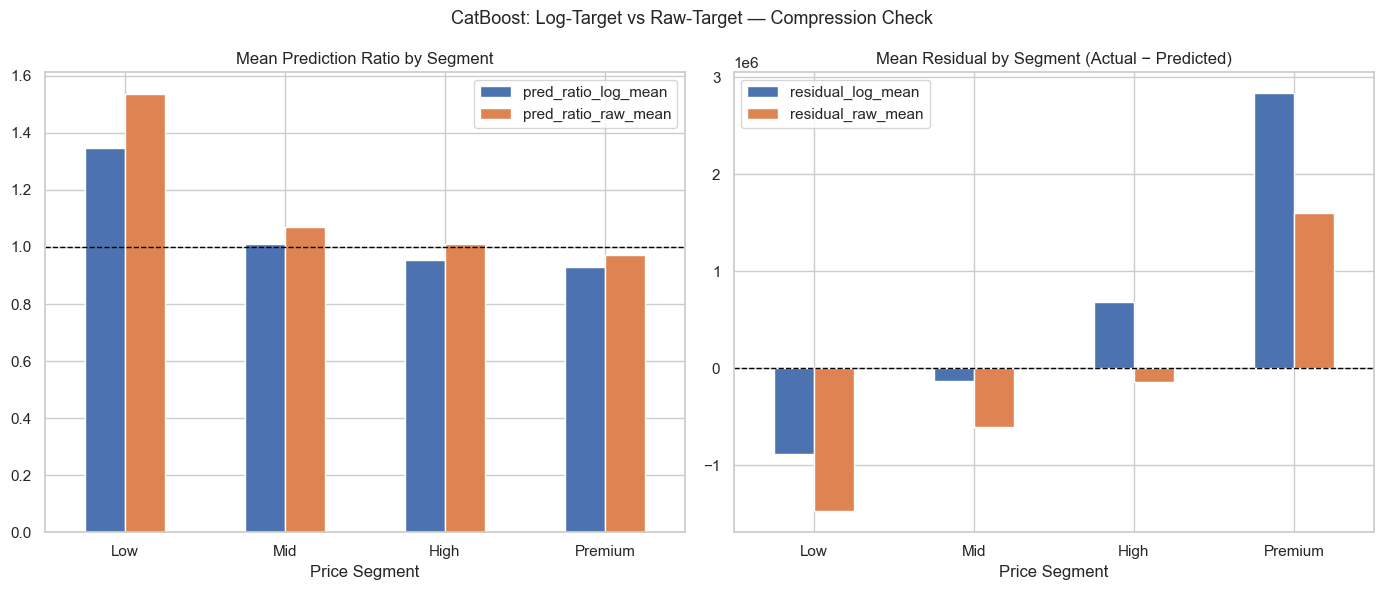

⚠ Log-target has lower prediction ratio than raw-target in the Premium segment.
  This suggests log-transform compresses high-price predictions — underprediction bias.


In [26]:
# ── Compression plots ─────────────────────────────────────────────────────────
if comp_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    seg_comp.set_index('price_segment')[['pred_ratio_log_mean', 'pred_ratio_raw_mean']].plot(
        kind='bar', ax=axes[0], title='Mean Prediction Ratio by Segment'
    )
    axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Price Segment')
    axes[0].tick_params(axis='x', rotation=0)

    seg_comp.set_index('price_segment')[['residual_log_mean', 'residual_raw_mean']].plot(
        kind='bar', ax=axes[1], title='Mean Residual by Segment (Actual − Predicted)'
    )
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Price Segment')
    axes[1].tick_params(axis='x', rotation=0)

    plt.suptitle('CatBoost: Log-Target vs Raw-Target — Compression Check', fontsize=13)
    plt.tight_layout()
    plt.savefig(DIAGNOSTICS_DIR / 'catboost_log_vs_raw_compression_plot.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Interpretation
    if 'Premium' in seg_comp['price_segment'].values:
        prem = seg_comp[seg_comp['price_segment'] == 'Premium'].iloc[0]
        if prem['pred_ratio_log_mean'] < prem['pred_ratio_raw_mean']:
            print('⚠ Log-target has lower prediction ratio than raw-target in the Premium segment.')
            print('  This suggests log-transform compresses high-price predictions — underprediction bias.')
        else:
            print('✓ Log-target does not compress Premium predictions more than raw-target.')


## 13. Outlier and Data Quality Investigation

We flag cases that may be genuine data quality issues rather than hard-to-predict legitimate laptops. Flagged criteria:

- Absolute percentage error > 200%
- Very high actual price with very low predicted price (underprediction ratio < 0.5)
- Very low actual price with very high predicted price (overprediction ratio > 2.0)

> **Note**: No records are removed in this notebook. These are flagged for manual review only.

In [27]:
main_for_outliers = diag_df[
    (diag_df['model_name'] == 'CatBoost') & (diag_df['target_used'] == 'log_target_price')
].copy()

if merge_ok and available_cat_cols:
    main_for_outliers = main_for_outliers.merge(feat_subset, on='sample_id', how='left')

outlier_flags = (
    (main_for_outliers['absolute_percentage_error'] > 2.0) |
    (main_for_outliers['prediction_ratio'] < 0.5) |
    (main_for_outliers['prediction_ratio'] > 2.0)
)

potential_outliers = main_for_outliers[outlier_flags].copy()
print(f'Potential outliers flagged: {len(potential_outliers)} of {len(main_for_outliers)}')

out_cols = ['sample_id', 'actual_price', 'predicted_price', 'residual', 'absolute_percentage_error', 'prediction_ratio', 'price_segment']
if merge_ok:
    out_cols += available_cat_cols

potential_outliers[out_cols].to_csv(DIAGNOSTICS_DIR / 'potential_outlier_cases.csv', index=False)
display(potential_outliers[out_cols].sort_values('absolute_percentage_error', ascending=False).head(20))
print('\nSaved: potential_outlier_cases.csv')


Potential outliers flagged: 64 of 1461


,sample_id,actual_price,predicted_price,residual,absolute_percentage_error,prediction_ratio,price_segment
1225,3703,"3,500,000.0000","16,540,510.0981","-13,040,510.0981",3.7259,4.7259,Low
295,2845,"1,000,000.0000","4,622,047.4243","-3,622,047.4243",3.6220,4.6220,Low
612,1670,"1,300,000.0000","5,459,744.4555","-4,159,744.4555",3.1998,4.1998,Low
424,4365,"1,000,000.0000","4,086,562.4584","-3,086,562.4584",3.0866,4.0866,Low
1146,4467,"1,200,000.0000","4,892,300.0884","-3,692,300.0884",3.0769,4.0769,Low
128,2952,"2,500,000.0000","10,156,117.7633","-7,656,117.7633",3.0624,4.0624,Low
529,511,"3,900,000.0000","14,802,018.7913","-10,902,018.7913",2.7954,3.7954,Low
47,2577,"1,000,000.0000","3,416,444.7787","-2,416,444.7787",2.4164,3.4164,Low
404,3985,"1,800,000.0000","5,911,957.9686","-4,111,957.9686",2.2844,3.2844,Low
609,4302,"3,200,000.0000","10,470,027.3196","-7,270,027.3196",2.2719,3.2719,Low



Saved: potential_outlier_cases.csv


## 14. Correction Strategy Experiments

> **Disclaimer**: These experiments are **exploratory only**. Corrections are computed and evaluated on the same test set, which means the corrected metrics are optimistic and should not be reported as final model performance. Their purpose is to guide tuning strategy in notebook 10.

We test three post-hoc correction strategies on CatBoost + log_target_price:

1. **Additive segment correction**: add mean residual per segment
2. **Multiplicative segment correction**: multiply by median actual/predicted ratio per segment
3. **Premium-only correction**: apply correction only to Premium laptops

In [28]:
def evaluate_correction(actual, predicted_corrected, name):
    return {
        'correction': name,
        'mae': mean_absolute_error(actual, predicted_corrected),
        'rmse': root_mean_squared_error(actual, predicted_corrected),
        'mape': mean_absolute_percentage_error(actual, predicted_corrected),
        'r2': r2_score(actual, predicted_corrected),
    }


# Base data: CatBoost + log predictions
base = main_all.copy() if 'main_all' in dir() else diag_df[
    (diag_df['model_name'] == 'CatBoost') & (diag_df['target_used'] == 'log_target_price')
].copy()

actual_arr = base['actual_price'].values
predicted_arr = base['predicted_price'].values

# Compute segment statistics for corrections
seg_stats = base.groupby('price_segment', observed=True).agg(
    mean_residual=('residual', 'mean'),
    median_ratio=('prediction_ratio', 'median'),
).to_dict('index')

# Strategy 1: Additive correction
pred_additive = predicted_arr.copy()
for i, (seg, row) in enumerate(zip(base['price_segment'], predicted_arr)):
    if str(seg) in seg_stats:
        pred_additive[i] = row + seg_stats[str(seg)]['mean_residual']

# Strategy 2: Multiplicative correction
pred_multiplicative = predicted_arr.copy()
for i, (seg, row) in enumerate(zip(base['price_segment'], predicted_arr)):
    if str(seg) in seg_stats:
        ratio = seg_stats[str(seg)]['median_ratio']
        if ratio > 0:
            pred_multiplicative[i] = row / ratio  # correct upward if ratio < 1 (underprediction)

# Strategy 3: Premium-only additive
pred_premium_only = predicted_arr.copy()
if 'Premium' in seg_stats:
    prem_correction = seg_stats['Premium']['mean_residual']
    for i, seg in enumerate(base['price_segment']):
        if str(seg) == 'Premium':
            pred_premium_only[i] = pred_premium_only[i] + prem_correction

# Evaluate all strategies
correction_results = [
    evaluate_correction(actual_arr, predicted_arr, 'No correction (baseline)'),
    evaluate_correction(actual_arr, pred_additive, 'Additive segment correction'),
    evaluate_correction(actual_arr, pred_multiplicative, 'Multiplicative segment correction'),
    evaluate_correction(actual_arr, pred_premium_only, 'Premium-only additive correction'),
]

corr_df = pd.DataFrame(correction_results)
corr_df.to_csv(DIAGNOSTICS_DIR / 'correction_experiment_results.csv', index=False)
print('=== Correction Experiment Results (test-set estimates — optimistic!) ===')
display(corr_df)


=== Correction Experiment Results (test-set estimates — optimistic!) ===


,correction,mae,rmse,mape,r2
0,No correction (baseline),"3,252,280.8663","5,157,061.3893",0.2771,0.8930
1,Additive segment correction,"3,126,966.5211","4,928,941.7973",0.2579,0.9022
2,Multiplicative segment correction,"3,261,340.0378","5,248,928.9053",0.2572,0.8891
3,Premium-only additive correction,"3,172,086.5776","4,961,708.3974",0.2757,0.9009


In [29]:
# ── Premium metrics after each correction ────────────────────────────────────
prem_idx = base['price_segment'].astype(str) == 'Premium'
prem_actual = actual_arr[prem_idx]

prem_correction_results = []
for pred_arr_variant, label in [
    (predicted_arr, 'No correction'),
    (pred_additive, 'Additive'),
    (pred_multiplicative, 'Multiplicative'),
    (pred_premium_only, 'Premium-only'),
]:
    prem_pred = pred_arr_variant[prem_idx]
    prem_correction_results.append({
        'correction': label,
        'premium_mae': mean_absolute_error(prem_actual, prem_pred),
        'premium_rmse': root_mean_squared_error(prem_actual, prem_pred),
        'premium_mape': mean_absolute_percentage_error(prem_actual, prem_pred),
        'premium_underprediction_rate': ((prem_actual - prem_pred) > 0).mean(),
    })

print('=== Premium Segment Metrics After Corrections ===')
display(pd.DataFrame(prem_correction_results))
print('\nNote: these are test-set estimates. Real gain must be validated via cross-validation in notebook 10.')


=== Premium Segment Metrics After Corrections ===


,correction,premium_mae,premium_rmse,premium_mape,premium_underprediction_rate
0,No correction,"6,941,901.9028","9,150,915.4961",0.2082,0.6323
1,Additive,"6,615,540.1878","8,700,268.4545",0.2026,0.4735
2,Multiplicative,"7,076,117.4257","9,310,462.0657",0.2143,0.4986
3,Premium-only,"6,615,540.1878","8,700,268.4545",0.2026,0.4735



Note: these are test-set estimates. Real gain must be validated via cross-validation in notebook 10.


## 15. Recommendations for Notebook 10

Based on the diagnostics above, we summarize the key findings and recommended actions for the hyperparameter tuning notebook.

In [34]:
recommendation_text = """
=============================================================
MODEL DIAGNOSTICS RECOMMENDATIONS 
=============================================================

Generated from: 09_model_diagnostics_and_error_analysis.ipynb

CONFIRMED FINDINGS
------------------
1. Heteroscedasticity detected:
   - Residual variance increases with actual laptop price.
   - This does not invalidate tree-based models but means global RMSE
     understates errors in the Premium segment.
   - Implication: use segment-level metrics during tuning, not only global RMSE.

2. Premium segment underprediction:
   - CatBoost + log_target_price tends to underpredict high-price laptops.
   - CatBoost + target_price has lower Premium underprediction.
   - The log transform compresses high-price predictions (prediction_ratio < 1 in Premium).

3. Low-price segment overprediction:
   - Low-price laptops are overpredicted by both CatBoost variants.
   - This is consistent with mean-reversion in tree models trained on a skewed target.

4. Log-target trade-off:
   - log_target_price improves Low, Mid, and High segment metrics (MAE, MAPE).
   - log_target_price worsens Premium segment metrics relative to raw target_price.
   - Both CatBoost variants remain strong candidates for tuning.

DIAGNOSTIC HYPOTHESES (not yet confirmed)
-----------------------------------------
- Feature-level bias may exist for specific brands or CPU/GPU configurations.
  -> Inspect feature_level_error_summary.csv and confirm in tuning.
- Some potential outliers may be data quality issues rather than hard cases.
  -> Inspect potential_outlier_cases.csv; do not remove without verification.

RECOMMENDATIONS FOR NOTEBOOK 10
--------------------------------
1. Primary models to tune:
   - CatBoost + log_target_price (best global performance)
   - CatBoost + target_price (more robust for Premium)
   - LightGBM + log_target_price
   - LightGBM + target_price
   - Optional: Extra Trees + log_target_price

2. Use cross-validation (at minimum 5-fold) during tuning.
   - Evaluate on original price scale, not log scale.

3. Track metrics by price segment, not only global RMSE:
   - MAE_overall, RMSE_overall, MAPE_overall
   - MAE_Premium, RMSE_Premium, MAPE_Premium
   - MAE_Low, MAPE_Low

4. Consider sample weighting for the Premium segment:
   - CatBoost supports sample_weight parameter.
   - Weight Premium samples higher if Premium underprediction is a priority.

5. Consider multi-objective model selection:
   - Score = RMSE + MAE + Premium_MAE + MAPE (weighted combination)
   - Avoids selecting a model that wins globally but fails in Premium.

6. Consider adding engineered features if feature-level bias is confirmed:
   - Price tier indicators, high-end GPU flags, brand-tier encoding.

7. Do not remove suspected outliers unless manually verified.
   - Flag them and check their influence on tuning via model-with and model-without tests.

8. Log-target correction:
   - Additive or multiplicative segment corrections show promise in test-set estimates.
   - Validate these approaches via cross-validation before applying.
   - Alternatively, train a lightweight calibration model on residuals (stacking approach).
"""

print(recommendation_text)

rec_path = DIAGNOSTICS_DIR / 'model_diagnostics_recommendation.txt'
rec_path.write_text(recommendation_text.strip())
print(f'\nSaved: {rec_path}')



MODEL DIAGNOSTICS RECOMMENDATIONS 

Generated from: 09_model_diagnostics_and_error_analysis.ipynb

CONFIRMED FINDINGS
------------------
1. Heteroscedasticity detected:
   - Residual variance increases with actual laptop price.
   - This does not invalidate tree-based models but means global RMSE
     understates errors in the Premium segment.
   - Implication: use segment-level metrics during tuning, not only global RMSE.

2. Premium segment underprediction:
   - CatBoost + log_target_price tends to underpredict high-price laptops.
   - CatBoost + target_price has lower Premium underprediction.
   - The log transform compresses high-price predictions (prediction_ratio < 1 in Premium).

3. Low-price segment overprediction:
   - Low-price laptops are overpredicted by both CatBoost variants.
   - This is consistent with mean-reversion in tree models trained on a skewed target.

4. Log-target trade-off:
   - log_target_price improves Low, Mid, and High segment metrics (MAE, MAPE).
   - l

In [32]:
# ── Final output file summary ─────────────────────────────────────────────────
print('=== Output Files Saved to:', DIAGNOSTICS_DIR, '===')
for f in sorted(DIAGNOSTICS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<60}  {size_kb:6.1f} KB')


=== Output Files Saved to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling\model_diagnostics ===
  catboost_log_vs_raw_compression_check.csv                        0.6 KB
  catboost_log_vs_raw_compression_plot.png                        65.3 KB
  correction_experiment_results.csv                                0.4 KB
  diagnostic_errors_long.csv                                    1277.2 KB
  diagnostic_model_error_summary.csv                               1.3 KB
  heteroscedasticity_binned_error_summary.csv                      7.5 KB
  heteroscedasticity_CatBoost_log_target_price.png               220.0 KB
  heteroscedasticity_CatBoost_target_price.png                   216.9 KB
  heteroscedasticity_ExtraTrees_log_target_price.png             212.5 KB
  heteroscedasticity_LightGBM_log_target_price.png               216.7 KB
  heteroscedasticity_LightGBM_target_price.png                   219.1 KB
  low_price_segment_diagnostics.csv                                0.8 KB
  low_pric